# Updated Code

In [1]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 3.2.1
    Uninstalling sentence-transformers-3.2.1:
      Successfully uninstalled sentence-transformers-3.2.1


In [2]:
import json
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import json

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from pathlib import Path
import pandas as pd
import re
import torch
from sklearn.model_selection import train_test_split


In [172]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [205]:
data_path1 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e5_DR01_reformat_preds_raw.xlsx")
data_path2 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e5_DR1_preds_final.xlsx")
data_path3 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e5_DR0_reformat_preds_final.xlsx")
data_path4 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e5_DR0_reformat_full_preds_final.xlsx")
data_path5 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e5_DR0_preds_final.xlsx")
data_path6 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e4_DR0.1_preds_final.xlsx")
data_path7 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e4_DR0_preds_final.xlsx")
data_path8 = Path("/content/drive/My Drive/Val_results/llama_3B_LR1e5_DR01_preds_raw.xlsx")
data_path9 = Path("/content/drive/My Drive/Val_results/llama_3B_LR1e5_DR0_preds_raw.xlsx")
data_path10 = Path("/content/drive/My Drive/Val_results/dpo_model_5e7_b003_final.xlsx")
data_path11 = Path("/content/drive/My Drive/Val_results/DPO_LR5e7_B01_preds_raw.xlsx")
data_path12 = Path("/content/drive/My Drive/Val_results/llama_3B_LR2e5_DR0_boosted_preds_raw.xlsx")
data_path13 = Path("/content/drive/My Drive/Val_results/baseline.xlsx")
data_path14 = Path("/content/drive/My Drive/Val_results/DPO_LR5e6_B01_preds_raw.xlsx")
data_path15 = Path("/content/drive/My Drive/llama_3B_LR2e5_DR01_reformat_test_set.xlsx")


lr2e5_dr01_reformat = pd.read_excel(data_path1.as_posix())
lr2e5_dr01 = pd.read_excel(data_path2.as_posix())
lr2e5_dr0_reformat = pd.read_excel(data_path3.as_posix())
lr2e5_dr0_reformat_full = pd.read_excel(data_path4.as_posix())
lr2e5_dr0 = pd.read_excel(data_path5.as_posix())
lr2e4_dr01 = pd.read_excel(data_path6.as_posix())
lr2e4_dr0 = pd.read_excel(data_path7.as_posix())
lr1e5_dr01 = pd.read_excel(data_path8.as_posix())
lr1e5_dr0 = pd.read_excel(data_path9.as_posix())
dpo_5e7_b03 = pd.read_excel(data_path10.as_posix())
dpo_5e7_b01 = pd.read_excel(data_path11.as_posix())
lr2e5_boosted = pd.read_excel(data_path12.as_posix())
baseline = pd.read_excel(data_path13.as_posix())
dpo_5e6_b01 = pd.read_excel(data_path14.as_posix())
lr2e5_dr01_reformat_test = pd.read_excel(data_path15.as_posix())

In [194]:
data_path = Path("/content/drive/My Drive/labeled_data_5k_final.xlsx")
data_path2 = Path("/content/drive/My Drive/labeled_data_5k_final2.xlsx")

df = pd.read_excel(data_path.as_posix())
df2 = pd.read_excel(data_path2.as_posix())


labeled_df = df[["id","reformatted", "label"]]
labeled_df2 = df2[["id","reformatted", "label"]]

# Create train, validation, test split 1
train_df, test_df_temp = train_test_split(labeled_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_df_temp, test_size=0.5, random_state=42)
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

print("")

# Create train, validation, test split 2
train_df2, test_df_temp2 = train_test_split(labeled_df2, test_size=0.3, random_state=42)
test_df2, val_df2 = train_test_split(test_df_temp2, test_size=0.5, random_state=42)
print(f"Train size 2: {len(train_df2)}")
print(f"Validation size 2: {len(val_df2)}")
print(f"Test size 2: {len(test_df2)}")


train_df_full = pd.concat([train_df, train_df2], ignore_index=True)
val_df_full = pd.concat([val_df, val_df2], ignore_index=True)
test_df_full = pd.concat([test_df, test_df2], ignore_index=True)

print(train_df_full.shape)
print(val_df_full.shape)
print(test_df_full.shape)

Train size: 3500
Validation size: 750
Test size: 750

Train size 2: 3500
Validation size 2: 750
Test size 2: 750
(7000, 3)
(1500, 3)
(1500, 3)


In [197]:
data_path3 = Path("/content/test_set_sample_500.xlsx")
test_df_sample = pd.read_excel(data_path3.as_posix())
print(test_df_sample.shape)
test_df_sample.head()

(500, 4)


,id,description,reformatted,label
0,d9c3654b-4197-48fb-af34-945f392203d7,Job Role: ETL Developer with Teradata & RedShi...,```markdown\n# Job Title: ETL Developer with T...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
1,bb6d9bfe-a1a3-4046-b140-188041f08859,This Jobot Job is hosted by: Crystal HarveyAre...,```markdown\n# Job Title: Full Time Help Desk ...,"{""Required"":{""Education"":[],""Experience"":[{""in..."
2,c210b3c1-6250-4d4d-8d83-f1252e362b63,TEKsystems is looking for a Cloud Security Con...,```markdown\n# Job Title: Cloud Security Contr...,"{""Required"":{""Education"":[],""Experience"":[],""C..."
3,e75319e3-2dfa-4157-ac25-4532d7dc2e08,Senior Salesforce Data Cloud EngineerJob Summa...,```markdown\n# Senior Salesforce Data Cloud En...,"{""Required"":{""Education"":[],""Experience"":[],""C..."
4,8920d0cd-e326-46fe-8809-d32096843518,Trigyn direct client has long term contract op...,```markdown\n# Business Analyst\n\n## Descript...,"{""Required"":{""Education"":[],""Experience"":[{""in..."


In [198]:
# Rename the 'label' column in test_df_full to 'orig_label'
test_df_full_renamed = test_df_full.rename(columns={'label': 'orig_label'})

# Perform the left join on the 'id' column
test_df_sample = test_df_sample.merge(test_df_full_renamed[['id', 'orig_label']], on='id', how='left')

# Display the result
print(test_df_sample)

                                       id  \
0    d9c3654b-4197-48fb-af34-945f392203d7   
1    bb6d9bfe-a1a3-4046-b140-188041f08859   
2    c210b3c1-6250-4d4d-8d83-f1252e362b63   
3    e75319e3-2dfa-4157-ac25-4532d7dc2e08   
4    8920d0cd-e326-46fe-8809-d32096843518   
..                                    ...   
496  30758f86-aa70-4ad7-a008-c97e248453c4   
497  49c2a3d0-2862-45ab-8ea9-5e3dc4b310d9   
498  0fa958c8-e952-433e-a242-50ffd036f0db   
499  f3506889-2fe4-4fc7-8370-f091e4e7335c   
500  64bf1fb8-8a03-419a-98c7-ab0507da6eb2   

                                           description  \
0    Job Role: ETL Developer with Teradata & RedShi...   
1    This Jobot Job is hosted by: Crystal HarveyAre...   
2    TEKsystems is looking for a Cloud Security Con...   
3    Senior Salesforce Data Cloud EngineerJob Summa...   
4    Trigyn direct client has long term contract op...   
..                                                 ...   
496  Title: Events ManagerDuration: 6 MonthsLocatio..

# Match Score with Precompute embeddings

In [8]:
import pandas as pd
import numpy as np
import json
import torch
from sentence_transformers import SentenceTransformer

# Load model on GPU if available or CPU otherwise
model = SentenceTransformer("jinaai/jina-embeddings-v3", trust_remote_code=True, device='cuda' if torch.cuda.is_available() else 'cpu')


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/734k [00:00<?, ?B/s]

custom_st.py:   0%|          | 0.00/8.78k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/192 [00:00<?, ?B/s]

In [206]:
# Core attributes for each category
cat_cores = {
    'Technical_skills': 'skill_name',
    'Education': 'education_level',
    'Credentials': 'credential',
    'Experience': 'experience_desc'
}

def safe_get(d, keys):
    v = d
    for k in keys:
        v = v.get(k, [])
    return v

def compute_category_metrics(TP, FP, FN):
    if TP == 0 and FP == 0 and FN == 0:
        return 1.0, 1.0, 1.0
    precision = TP/(TP+FP) if (TP+FP)>0 else 0.0
    recall = TP/(TP+FN) if (TP+FN)>0 else 0.0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall)>0 else 0.0
    return precision, recall, f1

def extract_all_strings_from_json(j):
    result = []
    if isinstance(j, dict):
        for v in j.values():
            result.extend(extract_all_strings_from_json(v))
    elif isinstance(j, list):
        for item in j:
            if isinstance(item, str):
                s = item.strip()
                if s:
                    result.append(s)
            else:
                result.extend(extract_all_strings_from_json(item))
    return result

def precompute_embeddings_for_df(df, label_col='label_json', pred_col='prediction_json'):
    all_strings = set()
    for idx, row in df.iterrows():
        label_j = row[label_col]
        pred_j = row[pred_col]
        if label_j is not None and not (isinstance(label_j, float) and np.isnan(label_j)):
            label_strings = extract_all_strings_from_json(label_j)
            for s in label_strings:
                all_strings.add(s)
        if pred_j is not None and not (isinstance(pred_j, float) and np.isnan(pred_j)):
            pred_strings = extract_all_strings_from_json(pred_j)
            for s in pred_strings:
                all_strings.add(s)
    all_strings = list(all_strings)

    if all_strings:
        embeddings = model.encode(all_strings, batch_size=64)
    else:
        embeddings = np.zeros((0, 384))

    string_to_emb = {s: emb for s, emb in zip(all_strings, embeddings)}
    return string_to_emb

def get_embedding(s, string_to_emb):
    s = s.strip()
    return string_to_emb.get(s, None)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b))

def text_similarity(text1, text2, string_to_emb, threshold=0.75):
    if (not text1 or not text1.strip()) and (not text2 or not text2.strip()):
        return 1.0
    if (not text1 or not text1.strip()) or (not text2 or not text2.strip()):
        return 0.0
    emb1 = get_embedding(text1, string_to_emb)
    emb2 = get_embedding(text2, string_to_emb)
    if emb1 is None or emb2 is None:
        return 0.0
    sim = cosine_similarity(emb1, emb2)
    return sim if sim >= threshold else 0.0

def array_to_best_match_similarity(label_values, pred_values, string_to_emb, threshold=0.75):
    # Ensure lists
    if not isinstance(label_values, list):
        label_values = [label_values]
    if not isinstance(pred_values, list):
        pred_values = [pred_values]

    label_values_str = [str(v).strip() for v in label_values if v is not None]
    pred_values_str = [str(v).strip() for v in pred_values if v is not None]

    if (not label_values_str or all(not v for v in label_values_str)) and (not pred_values_str or all(not v for v in pred_values_str)):
        return 1.0
    if not label_values_str or all(not v for v in label_values_str):
        return 1.0
    if not pred_values_str or all(not v for v in pred_values_str):
        return 0.0

    match_count = 0
    for lv in label_values_str:
        if not lv:
            match_count += 1
            continue
        best_sim = 0.0
        for pv in pred_values_str:
            if not pv:
                continue
            sim = text_similarity(lv, pv, string_to_emb, threshold=threshold)
            if sim > best_sim:
                best_sim = sim
        match_count += (best_sim > 0.0)
    return match_count / len([x for x in label_values_str if x])

def compute_requirement_match(label_req, pred_req, core_attr_name, string_to_emb, threshold=0.75):
    if not isinstance(label_req, dict):
        raise TypeError(f"label_req is not a dict: {label_req}")
    if not isinstance(pred_req, dict):
        raise TypeError(f"pred_req is not a dict: {pred_req}")

    label_core = label_req.get(core_attr_name, [])
    pred_core = pred_req.get(core_attr_name, [])

    # Ensure these are lists
    if not isinstance(label_core, list):
        label_core = [label_core]
    if not isinstance(pred_core, list):
        pred_core = [pred_core]

    label_attrs = {k:v for k,v in label_req.items() if k != core_attr_name}
    pred_attrs = {k:v for k,v in pred_req.items() if k != core_attr_name}

    other_attr_keys = set(label_attrs.keys()) | set(pred_attrs.keys())
    num_other_attrs = len(other_attr_keys)
    other_attr_weight = 0.5 / num_other_attrs if num_other_attrs > 0 else 0.5

    core_match_fraction = array_to_best_match_similarity(label_core, pred_core, string_to_emb, threshold=threshold)
    core_score = core_match_fraction * 0.5

    other_score = 0.0
    for attr in other_attr_keys:
        label_val = label_attrs.get(attr, [])
        pred_val = pred_attrs.get(attr, [])
        if not isinstance(label_val, list):
            label_val = [label_val]
        if not isinstance(pred_val, list):
            pred_val = [pred_val]
        if not label_val and not pred_val:
            attr_match = 1.0
        else:
            if label_val and all(isinstance(x,int) for x in label_val):
                attr_match = 1.0 if set(label_val) == set(pred_val) else 0.0
            else:
                attr_match = array_to_best_match_similarity(label_val, pred_val, string_to_emb, threshold=threshold)
        other_score += attr_match * other_attr_weight

    total_score = core_score + other_score
    return total_score

def match_requirements_single_category(label_list, pred_list, core_attr_name, string_to_emb, threshold=0.75):
    # If both empty, consider it a perfect classification => return (1,0,0)
    if (not label_list or len(label_list)==0) and (not pred_list or len(pred_list)==0):
        return 1,0,0

    TP = 0.0
    matched_preds = set()

    if not isinstance(label_list, list):
        label_list = [label_list]
    if not isinstance(pred_list, list):
        pred_list = [pred_list]

    for lreq in label_list:
        if not isinstance(lreq, dict):
            # If lreq is not a dict, skip or raise error
            continue
        best_score = 0.0
        best_pred_idx = None
        for p_idx, preq in enumerate(pred_list):
            if not isinstance(preq, dict):
                continue
            if p_idx in matched_preds:
                continue
            score = compute_requirement_match(lreq, preq, core_attr_name, string_to_emb, threshold=threshold)
            if score > best_score:
                best_score = score
                best_pred_idx = p_idx
        if best_pred_idx is not None and best_score > 0:
            TP += best_score
            matched_preds.add(best_pred_idx)

    FN = len(label_list) - len(matched_preds)
    FP = len(pred_list) - len(matched_preds)
    return TP, FP, FN

def compute_all_metrics_for_row(label_json, pred_json, string_to_emb, threshold=0.75):
    # Ensure label_json and pred_json are dict
    if isinstance(label_json, str):
        try:
            label_json = json.loads(label_json)
        except:
            raise ValueError("label_json is not valid JSON or dictionary")
    if isinstance(pred_json, str):
        try:
            pred_json = json.loads(pred_json)
        except:
            raise ValueError("prediction_json is not valid JSON or dictionary")

    def get_all(cat):
        return (safe_get(label_json, ['Required', cat]) + safe_get(label_json, ['Preferred', cat]),
                safe_get(pred_json, ['Required', cat]) + safe_get(pred_json, ['Preferred', cat]))

    (label_tech, pred_tech) = get_all('Technical_skills')
    (label_exp, pred_exp) = get_all('Experience')
    (label_edu, pred_edu) = get_all('Education')
    (label_cred, pred_cred) = get_all('Credentials')


    TP_tech, FP_tech, FN_tech = match_requirements_single_category(label_tech, pred_tech, cat_cores['Technical_skills'], string_to_emb, threshold)
    TP_exp, FP_exp, FN_exp = match_requirements_single_category(label_exp, pred_exp, cat_cores['Experience'], string_to_emb, threshold)
    TP_edu, FP_edu, FN_edu = match_requirements_single_category(label_edu, pred_edu, cat_cores['Education'], string_to_emb, threshold)
    TP_cred, FP_cred, FN_cred = match_requirements_single_category(label_cred, pred_cred, cat_cores['Credentials'], string_to_emb, threshold)

    def get_section(cat, section):
        return safe_get(label_json, [section, cat]), safe_get(pred_json, [section, cat])

    req_tech_label, req_tech_pred = get_section('Technical_skills','Required')
    pref_tech_label, pref_tech_pred = get_section('Technical_skills','Preferred')
    TP_req_tech, FP_req_tech, FN_req_tech = match_requirements_single_category(req_tech_label, req_tech_pred, cat_cores['Technical_skills'], string_to_emb, threshold)
    TP_pref_tech, FP_pref_tech, FN_pref_tech = match_requirements_single_category(pref_tech_label, pref_tech_pred, cat_cores['Technical_skills'], string_to_emb, threshold)

    req_exp_label, req_exp_pred = get_section('Experience','Required')
    pref_exp_label, pref_exp_pred = get_section('Experience','Preferred')
    TP_req_exp, FP_req_exp, FN_req_exp = match_requirements_single_category(req_exp_label, req_exp_pred, cat_cores['Experience'], string_to_emb, threshold)
    TP_pref_exp, FP_pref_exp, FN_pref_exp = match_requirements_single_category(pref_exp_label, pref_exp_pred, cat_cores['Experience'], string_to_emb, threshold)

    req_edu_label, req_edu_pred = get_section('Education','Required')
    TP_req_edu, FP_req_edu, FN_req_edu = match_requirements_single_category(req_edu_label, req_edu_pred, cat_cores['Education'], string_to_emb, threshold)
    pref_edu_label, pref_edu_pred = get_section('Education','Preferred')
    TP_pref_edu, FP_pref_edu, FN_pref_edu = match_requirements_single_category(pref_edu_label, pref_edu_pred, cat_cores['Education'], string_to_emb, threshold)

    req_cred_label, req_cred_pred = get_section('Credentials','Required')
    TP_req_cred, FP_req_cred, FN_req_cred = match_requirements_single_category(req_cred_label, req_cred_pred, cat_cores['Credentials'], string_to_emb, threshold)
    pref_cred_label, pref_cred_pred = get_section('Credentials','Preferred')
    TP_pref_cred, FP_pref_cred, FN_pref_cred = match_requirements_single_category(pref_cred_label, pref_cred_pred, cat_cores['Credentials'], string_to_emb, threshold)

    # Aggregate
    TP_tech_total = TP_req_tech + TP_pref_tech
    FP_tech_total = FP_req_tech + FP_pref_tech
    FN_tech_total = FN_req_tech + FN_pref_tech

    TP_exp_total = TP_req_exp + TP_pref_exp
    FP_exp_total = FP_req_exp + FP_pref_exp
    FN_exp_total = FN_req_exp + FN_pref_exp

    TP_edu_total = TP_req_edu + TP_pref_edu
    FP_edu_total = FP_req_edu + FP_pref_edu
    FN_edu_total = FN_req_edu + FN_pref_edu

    TP_cred_total = TP_req_cred + TP_pref_cred
    FP_cred_total = FP_req_cred + FP_pref_cred
    FN_cred_total = FN_req_cred + FN_pref_cred

    TP_req_all = TP_req_tech + TP_req_edu + TP_req_cred + TP_req_exp
    FP_req_all = FP_req_tech + FP_req_edu + FP_req_cred + FP_req_exp
    FN_req_all = FN_req_tech + FN_req_edu + FN_req_cred + FN_req_exp

    TP_pref_all = TP_pref_tech + TP_pref_edu + TP_pref_cred + TP_pref_exp
    FP_pref_all = FP_pref_tech + FP_pref_edu + FP_pref_cred + FP_pref_exp
    FN_pref_all = FN_pref_tech + FN_pref_edu + FN_pref_cred + FN_pref_exp

    TP_total = TP_tech_total + TP_edu_total + TP_cred_total + TP_exp_total
    FP_total = FP_tech_total + FP_edu_total + FP_cred_total + FP_exp_total
    FN_total = FN_tech_total + FN_edu_total + FN_cred_total + FN_exp_total

    metrics = {}
    def add_metrics(prefix, TP, FP, FN):
        p,r,f = compute_category_metrics(TP,FP,FN)
        metrics[f"{prefix}_precision"] = p
        metrics[f"{prefix}_recall"] = r
        metrics[f"{prefix}_f1"] = f

    categories = [
        "total",
        "required",
        "preferred",
        "technical_skills",
        "education",
        "credentials",
        "experience",
        "required_technical_skills",
        "required_education",
        "required_credentials",
        "required_experience",
        "preferred_technical_skills",
        "preferred_education",
        "preferred_credentials",
        "preferred_experience"
    ]

    add_metrics("total", TP_total, FP_total, FN_total)
    add_metrics("required", TP_req_all, FP_req_all, FN_req_all)
    add_metrics("preferred", TP_pref_all, FP_pref_all, FN_pref_all)
    add_metrics("technical_skills", TP_tech_total, FP_tech_total, FN_tech_total)
    add_metrics("education", TP_edu_total, FP_edu_total, FN_edu_total)
    add_metrics("credentials", TP_cred_total, FP_cred_total, FN_cred_total)
    add_metrics("experience", TP_exp_total, FP_exp_total, FN_exp_total)
    add_metrics("required_technical_skills", TP_req_tech, FP_req_tech, FN_req_tech)
    add_metrics("required_education", TP_req_edu, FP_req_edu, FN_req_edu)
    add_metrics("required_credentials", TP_req_cred, FP_req_cred, FN_req_cred)
    add_metrics("required_experience", TP_req_exp, FP_req_exp, FN_req_exp)
    add_metrics("preferred_technical_skills", TP_pref_tech, FP_pref_tech, FN_pref_tech)
    add_metrics("preferred_education", TP_pref_edu, FP_pref_edu, FN_pref_edu)
    add_metrics("preferred_credentials", TP_pref_cred, FP_pref_cred, FN_pref_cred)
    add_metrics("preferred_experience", TP_pref_exp, FP_pref_exp, FN_pref_exp)

    return metrics

def compute_scores_for_df(df, label_col='label_json', pred_col='prediction_json', threshold=0.75):
    # Convert JSON columns if still strings
    df[label_col] = df[label_col].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df[pred_col] = df[pred_col].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

    string_to_emb = precompute_embeddings_for_df(df, label_col=label_col, pred_col=pred_col)

    # Identify all metrics keys for zero metrics in case of null predictions
    categories = [
        "total",
        "required",
        "preferred",
        "technical_skills",
        "education",
        "credentials",
        "experience",
        "required_technical_skills",
        "required_education",
        "required_credentials",
        "required_experience",
        "preferred_technical_skills",
        "preferred_education",
        "preferred_credentials",
        "preferred_experience"
    ]
    metric_keys = []
    for cat in categories:
        metric_keys.extend([f"{cat}_precision", f"{cat}_recall", f"{cat}_f1"])

    def zero_metrics():
        return {k:0.0 for k in metric_keys}

    def process_row(row):
        if row[pred_col] is None or (isinstance(row[pred_col], float) and np.isnan(row[pred_col])):
            # prediction_json is null
            return zero_metrics()
        else:
            return compute_all_metrics_for_row(row[label_col], row[pred_col], string_to_emb, threshold=threshold)

    all_results = df.apply(process_row, axis=1)
    results_df = pd.DataFrame(all_results.tolist(), index=df.index)
    df = pd.concat([df, results_df], axis=1)
    return df

def aggregate_scores(df):
    metric_cols = [c for c in df.columns if c.endswith('_precision') or c.endswith('_recall') or c.endswith('_f1')]
    agg = df[metric_cols].mean()
    return agg.to_dict()


# Assess Indeterminate Impact

In [201]:
df_test = test_df_sample.copy()
df_test['label_json'] = df_test['label'].apply(json.loads)
# Safely parse JSON with error handling
def safe_json_loads(val):
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):  # Catch JSON errors and type errors
        return None

df_test['prediction_json'] = df_test['orig_label'].apply(safe_json_loads)
#df_test = df_test.dropna(subset=['label_json', 'prediction_json']).copy()
print(f"Number of Nulls resulting in 0 scores: {df_test['prediction_json'].isna().sum()}\n")
df_scored = compute_scores_for_df(df_test)
final_scores = aggregate_scores(df_scored)
print(final_scores)

Number of Nulls resulting in 0 scores: 0

{'total_precision': 0.9066942865211991, 'total_recall': 0.9123775586337015, 'total_f1': 0.9016914538948146, 'required_precision': 0.9398008520681491, 'required_recall': 0.9347800456335376, 'required_f1': 0.9263482102298004, 'preferred_precision': 0.8875034052403008, 'preferred_recall': 0.9011329208503576, 'preferred_f1': 0.8700468746890032, 'technical_skills_precision': 0.8908807687666914, 'technical_skills_recall': 0.8931645259298799, 'technical_skills_f1': 0.872566792789981, 'education_precision': 0.9887368120901056, 'education_recall': 0.9896872920825016, 'education_f1': 0.9872920825016634, 'credentials_precision': 0.9871329380311417, 'credentials_recall': 0.989354624085163, 'credentials_f1': 0.9857915747452464, 'experience_precision': 0.8848674107558863, 'experience_recall': 0.9025959825277098, 'experience_f1': 0.8622213426067533, 'required_technical_skills_precision': 0.9252151864661705, 'required_technical_skills_recall': 0.91611731701116

# Assess Test Set

In [207]:
df_test = lr2e5_dr01_reformat_test.copy()
df_test['label_json'] = df_test['label'].apply(json.loads)
# Safely parse JSON with error handling
def safe_json_loads(val):
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):  # Catch JSON errors and type errors
        return None

df_test['prediction_json'] = df_test['unstructured_preds'].apply(safe_json_loads)
#df_test = df_test.dropna(subset=['label_json', 'prediction_json']).copy()
print(f"Number of Nulls resulting in 0 scores: {df_test['prediction_json'].isna().sum()}\n")
df_scored = compute_scores_for_df(df_test)
final_scores = aggregate_scores(df_scored)
print(final_scores)

Number of Nulls resulting in 0 scores: 2

{'total_precision': 0.8130903383681176, 'total_recall': 0.7977880715388105, 'total_f1': 0.7883150172315686, 'required_precision': 0.8512749791034036, 'required_recall': 0.8545847509900726, 'required_f1': 0.8204081948181294, 'preferred_precision': 0.8279822665613236, 'preferred_recall': 0.7829886993426335, 'preferred_f1': 0.7560662786245814, 'technical_skills_precision': 0.7638981139413351, 'technical_skills_recall': 0.7641459818197854, 'technical_skills_f1': 0.7189163380517632, 'education_precision': 0.9839405483405483, 'education_recall': 0.9698760233918129, 'education_f1': 0.9714275132275132, 'credentials_precision': 0.9735134502923977, 'credentials_recall': 0.9573192546016076, 'credentials_f1': 0.9579172753172752, 'experience_precision': 0.8201847217767216, 'experience_recall': 0.7595681418834559, 'experience_f1': 0.7313979658511883, 'required_technical_skills_precision': 0.7981707637990539, 'required_technical_skills_recall': 0.794475035043

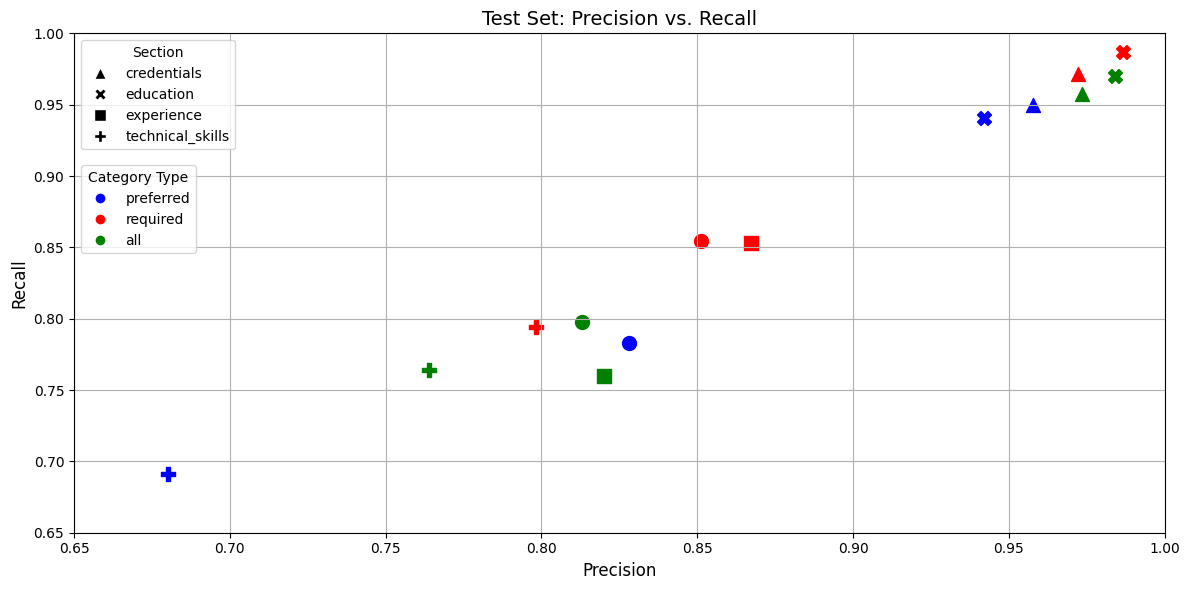

In [211]:
# Extract categories
categories = set()
for key in final_scores:
    if key.endswith('_precision'):
        categories.add(key.replace('_precision', ''))
    elif key.endswith('_recall'):
        categories.add(key.replace('_recall', ''))

# Function to determine "section" (main category)
def get_section(name):
    # Check known sections:
    if 'credentials' in name:
        return 'credentials'
    elif 'education' in name:
        return 'education'
    elif 'experience' in name:
        return 'experience'
    elif 'technical_skills' in name:
        return 'technical_skills'
    else:
        # If it doesn't match any known section, just return the name
        return name

# Function to determine category type (preferred, required, all)
def get_category_type(name):
    if 'preferred' in name:
        return 'preferred'
    elif 'required' in name:
        return 'required'
    else:
        return 'all'

# Assign markers per section
section_markers = {
    'credentials': '^',
    'education': 'X',
    'experience': 's',
    'technical_skills': 'P'
}

# Assign colors per category type
category_colors = {
    'preferred': 'blue',
    'required': 'red',
    'all': 'green'
}

data_points = []

for cat in categories:
    p_key = cat + '_precision'
    r_key = cat + '_recall'
    if p_key in final_scores and r_key in final_scores:
        precision = final_scores[p_key]
        recall = final_scores[r_key]
        section = get_section(cat)
        cat_type = get_category_type(cat)

        # Get marker and color
        marker = section_markers.get(section, 'o')  # default 'o' if not found
        color = category_colors.get(cat_type, 'black')  # default 'black' if not found

        data_points.append((precision, recall, section, cat_type, cat, marker, color))

plt.figure(figsize=(12, 6))

# Plot all points
for (precision, recall, section, cat_type, cat, marker, color) in data_points:
    plt.scatter(precision, recall, marker=marker, color=color, s=100)

plt.title('Test Set: Precision vs. Recall', fontsize=14)
plt.xlabel('Precision', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.grid(True)
plt.xlim(0.65, 1)
plt.ylim(0.65, 1)


# Legend for sections (markers)
section_handles = []
for sec, m in section_markers.items():
    section_handles.append(plt.Line2D([0], [0], marker=m, color='w', label=sec,
                                      markerfacecolor='black', markersize=8))

# Legend for category types (colors)
category_handles = []
for ctype, c in category_colors.items():
    category_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=ctype,
                                       markerfacecolor=c, markersize=8))

# Create two legends placed in the upper left
legend1 = plt.legend(handles=section_handles, title='Section', loc='upper left')
plt.gca().add_artist(legend1)

plt.legend(handles=category_handles, title='Category Type', loc='upper left',
           bbox_to_anchor=(0, 0.75))

plt.tight_layout()
plt.show()

In [126]:
# Sort df_test by 'total_f1' in ascending order
df_scored_sorted = df_scored.sort_values(by='total_f1', ascending=True)

df_scored_sorted


,id,reformatted,label,unstructured_preds,formatted_preds,json_preds,pydantic_preds,label_json,prediction_json,total_precision,...,preferred_technical_skills_f1,preferred_education_precision,preferred_education_recall,preferred_education_f1,preferred_credentials_precision,preferred_credentials_recall,preferred_credentials_f1,preferred_experience_precision,preferred_experience_recall,preferred_experience_f1
748,6f240672-084c-484b-8095-c1c3be4c2644,```markdown\n# Job Title: Sr. Python / DevOps ...,"{""Required"":{""Education"":[],""Experience"":[{""in...","{""Required"":{""Education"":[],""Experience"":[{""in...",NaN,NaN,NaN,"{'Required': {'Education': [], 'Experience': [...",None,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
641,83b4b3fa-6878-4e24-a673-29f10792fded,```markdown\n# Job Title: Java Backend Develop...,"{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...","{\n ""Required"": {\n ""Education"": [\n ...",NaN,Required=Requirements(Education=[Education(edu...,{'Required': {'Education': [{'field_of_study':...,None,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
247,77bea896-35ea-46c6-9555-96bd5f1579eb,```markdown\n# Job Title: Azure Cloud Lead Dev...,"{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...",NaN,NaN,NaN,{'Required': {'Education': [{'field_of_study':...,None,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
503,44c72f9b-1e94-4560-aa4c-d280cf899e7a,```markdown\n# Job Title: Scheduler Assistant ...,"{""Required"":{""Education"":[],""Experience"":[],""C...","{""Required"":{""Education"":[],""Experience"":[],""C...",NaN,NaN,NaN,"{'Required': {'Education': [], 'Experience': [...",None,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
267,fe6097b9-deb9-4e86-a943-47b03211042b,```markdown\n# Job Title: Systems Engineer\n\n...,"{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...","{\n ""Required"": {\n ""Education"": [\n ...",{'Required': {'Education': [{'field_of_study':...,Required=Requirements(Education=[Education(edu...,{'Required': {'Education': [{'field_of_study':...,{'Required': {'Education': [{'field_of_study':...,0.764706,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,1dfa6166-ec86-4a0f-9765-3cb2a35488cf,```markdown\n# Technical Project Manager\n\n##...,"{""Required"":{""Education"":[],""Experience"":[{""in...","{""Required"":{""Education"":[],""Experience"":[{""in...","{\n ""Required"": {\n ""Education"": [],\n ...","{'Required': {'Education': [], 'Experience': [...","Required=Requirements(Education=[], Experience...","{'Required': {'Education': [], 'Experience': [...","{'Required': {'Education': [], 'Experience': [...",1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
300,95a8aa5f-9f0e-46de-adf1-6722618c3c82,```markdown\n# Senior System Admin\n\n## Job R...,"{""Required"":{""Education"":[],""Experience"":[{""in...","{""Required"":{""Education"":[],""Experience"":[{""in...","{\n ""Required"": {\n ""Education"": [],\n ...","{'Required': {'Education': [], 'Experience': [...","Required=Requirements(Education=[], Experience...","{'Required': {'Education': [], 'Experience': [...","{'Required': {'Education': [], 'Experience': [...",1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
299,b331c041-9c25-4c51-acfc-8544ab1e870b,```markdown\n# Job Title: Graphic Designer\n\n...,"{""Required"":{""Education"":[],""Experience"":[{""in...","{""Required"":{""Education"":[],""Experience"":[{""in...","{\n ""Required"": {\n ""Education"": [],\n ...","{'Required': {'Education': [], 'Experience': [...","Required=Requirements(Education=[], Experience...","{'Required': {'Education': [], 'Experience': [...","{'Required': {'Education': [], 'Experience': [...",1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
454,4dc00be4-01fc-4d10-bd1d-

In [127]:
# Save Predictions
df_scored_sorted.to_excel('/content/results_analysis3.xlsx', index=False)

In [128]:
df_scored.head()

,id,reformatted,label,unstructured_preds,formatted_preds,json_preds,pydantic_preds,label_json,prediction_json,total_precision,...,preferred_technical_skills_f1,preferred_education_precision,preferred_education_recall,preferred_education_f1,preferred_credentials_precision,preferred_credentials_recall,preferred_credentials_f1,preferred_experience_precision,preferred_experience_recall,preferred_experience_f1
0,9dd929cc-072a-460d-8ad0-49ff9a356dca,```markdown\n# Job Title: SQL Server DBA\n\n##...,"{""Required"":{""Education"":[],""Experience"":[{""in...","{""Required"":{""Education"":[],""Experience"":[{""in...","{\n ""Required"": {\n ""Education"": [],\n ...","{'Required': {'Education': [], 'Experience': [...","Required=Requirements(Education=[], Experience...","{'Required': {'Education': [], 'Experience': [...","{'Required': {'Education': [], 'Experience': [...",1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
1,bb0084db-a27a-493e-8341-dc09348dfbaa,```markdown\n# Job Title: OIC Developer\n\n## ...,"{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...","{\n ""Required"": {\n ""Education"": [\n ...",{'Required': {'Education': [{'field_of_study':...,Required=Requirements(Education=[Education(edu...,{'Required': {'Education': [{'field_of_study':...,{'Required': {'Education': [{'field_of_study':...,0.773585,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,0.333333,0.5
2,783cf7ce-6ab4-438b-8db5-6a5e97b542f8,```markdown\n# Job Title: Systems Engineer\n\n...,"{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...","{\n ""Required"": {\n ""Education"": [\n ...",{'Required': {'Education': [{'field_of_study':...,Required=Requirements(Education=[Education(edu...,{'Required': {'Education': [{'field_of_study':...,{'Required': {'Education': [{'field_of_study':...,0.559055,...,0.0,1.0,1.0,1.0,1.0,0.2,0.333333,1.0,1.000000,1.0
3,41628488-45ac-401b-926c-020ca623658d,```markdown\n# Job Title: CX/Conversational AI...,"{""Required"":{""Education"":[],""Experience"":[],""C...","{""Required"":{""Education"":[],""Experience"":[],""C...","{\n ""Required"": {\n ""Education"": [],\n ...","{'Required': {'Education': [], 'Experience': [...","Required=Requirements(Education=[], Experience...","{'Required': {'Education': [], 'Experience': [...","{'Required': {'Education': [], 'Experience': [...",0.862267,...,0.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
4,ba33ae6b-7898-4c10-89f1-d418419f981b,```markdown\n# Job Title: Cyber Security Speci...,"{""Required"":{""Education"":[{""field_of_study"":[]...","{""Required"":{""Education"":[{""field_of_study"":[]...","{\n ""Required"": {\n ""Education"": [\n ...",{'Required': {'Education': [{'field_of_study':...,Required=Requirements(Education=[Education(edu...,{'Required': {'Education': [{'field_of_study':...,{'Required': {'Education': [{'field_of_study':...,0.586546,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0


In [ ]:
df_test['label_json'][2]

{'Required': {'Education': [{'field_of_study': ['Information Technology',
     'Related'],
    'education_level': ["Associate's", 'Vocational']}],
  'Experience': [{'industry': [],
    'minyears': [3],
    'experience_desc': ['related experience',
     'Tier II support',
     'Tier III support',
     'operations roles']}],
  'Credentials': [],
  'Technical_skills': [{'minyears': [0], 'skill_name': ['Windows Server']},
   {'minyears': [0],
    'skill_name': ['Visualization-based Microarchitecture Workbench', 'VMW']},
   {'minyears': [0], 'skill_name': ['MS Windows Server']},
   {'minyears': [0], 'skill_name': ['Active Directory']},
   {'minyears': [0], 'skill_name': ['GPO']},
   {'minyears': [0], 'skill_name': ['DNS']},
   {'minyears': [0], 'skill_name': ['DHCP']},
   {'minyears': [0], 'skill_name': ['Certificate Authority']},
   {'minyears': [0], 'skill_name': ['Azure AD']},
   {'minyears': [0], 'skill_name': ['ADFS']},
   {'minyears': [0], 'skill_name': ['IIS']},
   {'minyears': [0],


In [ ]:
df_test['prediction_json'][2]

{'Required': {'Education': [{'field_of_study': ['Information Technology',
     'Related'],
    'education_level': ["Associate's"]}],
  'Experience': [{'industry': [],
    'minyears': [3],
    'experience_desc': ['Work Experience']}],
  'Credentials': [],
  'Technical_skills': [{'minyears': [0],
    'skill_name': ['Windows Server',
     'Visualization-based Microarchitecture Workbench',
     'VMW']},
   {'minyears': [0],
    'skill_name': ['MS Windows Server environments',
     'MS Windows Server applications',
     'Windows Servers']},
   {'minyears': [0], 'skill_name': ['network backup', 'storage components']},
   {'minyears': [0],
    'skill_name': ['system monitoring',
     'system logs',
     'application logs',
     'hardware logs',
     'server logs',
     'storage logs']},
   {'minyears': [0],
    'skill_name': ['OS patches', 'administrative tools', 'utilities']},
   {'minyears': [0],
    'skill_name': ['server policies',
     'server procedures',
     'software installations']}

# Run All

In [190]:
def check_required_columns(dfs, required_columns=['label', 'unstructured_preds']):
    """
    Checks if each DataFrame in dfs contains all required_columns.

    Parameters:
        dfs (dict): A dictionary mapping names to dataframes, e.g. {'name': dataframe}.
        required_columns (list): A list of column names that must be present.

    Returns:
        None: Prints out messages for each DataFrame.
    """
    for name, df in dfs.items():
        if all(col in df.columns for col in required_columns):
            print(f"✅ {name} contains all required columns: {required_columns}")
        else:
            missing = [col for col in required_columns if col not in df.columns]
            print(f"❌ {name} is missing columns: {missing}")


# Example usage with your dataframes:
dataframes = {
    "lr2e5_dr01_reformat": lr2e5_dr01_reformat,
    "lr2e5_dr01": lr2e5_dr01,
    "lr2e5_dr0_reformat": lr2e5_dr0_reformat,
    "lr2e5_dr0_reformat_full": lr2e5_dr0_reformat_full,
    "lr2e5_dr0": lr2e5_dr0,
    "lr2e4_dr01": lr2e4_dr01,
    "lr2e4_dr0": lr2e4_dr0,
    "lr1e5_dr01": lr1e5_dr01,
    "lr1e5_dr0": lr1e5_dr0,
    "dpo_5e7_b03": dpo_5e7_b03,
    "dpo_5e7_b01": dpo_5e7_b01,
    "lr2e5_boosted": lr2e5_boosted,
    "baseline": baseline,
    "dpo_5e6_b01": dpo_5e6_b01

}

check_required_columns(dataframes)


✅ lr2e5_dr01_reformat contains all required columns: ['label', 'unstructured_preds']
✅ lr2e5_dr01 contains all required columns: ['label', 'unstructured_preds']
✅ lr2e5_dr0_reformat contains all required columns: ['label', 'unstructured_preds']
✅ lr2e5_dr0_reformat_full contains all required columns: ['label', 'unstructured_preds']
✅ lr2e5_dr0 contains all required columns: ['label', 'unstructured_preds']
✅ lr2e4_dr01 contains all required columns: ['label', 'unstructured_preds']
✅ lr2e4_dr0 contains all required columns: ['label', 'unstructured_preds']
✅ lr1e5_dr01 contains all required columns: ['label', 'unstructured_preds']
✅ lr1e5_dr0 contains all required columns: ['label', 'unstructured_preds']
✅ dpo_5e7_b03 contains all required columns: ['label', 'unstructured_preds']
✅ dpo_5e7_b01 contains all required columns: ['label', 'unstructured_preds']
✅ lr2e5_boosted contains all required columns: ['label', 'unstructured_preds']
✅ baseline contains all required columns: ['label', 'uns

In [191]:
lr2e5_dr01.head()

,id,description,label,unstructured_preds,formatted_preds,json_preds,pydantic_preds
0,9dd929cc-072a-460d-8ad0-49ff9a356dca,"Position: SQL Server DBALocation: Plano, TX (D...","{""Required"":{""Education"":[],""Experience"":[{""in...","{""Required"":{""Education"":[],""Experience"":[{""in...","{\n ""Required"": {\n ""Education"": [],\n ...",NaN,"Required=Requirements(Education=[], Experience..."
1,bb0084db-a27a-493e-8341-dc09348dfbaa,"Title - OIC DeveloperLocation - Watsonville, C...","{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...","{\n ""Required"": {\n ""Education"": [\n ...",NaN,Required=Requirements(Education=[Education(edu...
2,783cf7ce-6ab4-438b-8db5-6a5e97b542f8,The Systems Engineer will support the Windows ...,"{""Required"":{""Education"":[{""field_of_study"":[""...","{""Required"":{""Education"":[{""field_of_study"":[""...","{\n ""Required"": {\n ""Education"": [\n ...",NaN,Required=Requirements(Education=[Education(edu...
3,41628488-45ac-401b-926c-020ca623658d,"Hi, I hope you're doing well !! Momento USA...","{""Required"":{""Education"":[],""Experience"":[],""C...","{""Required"":{""Education"":[],""Experience"":[],""C...","{\n ""Required"": {\n ""Education"": [],\n ...",NaN,"Required=Requirements(Education=[], Experience..."
4,ba33ae6b-7898-4c10-89f1-d418419f981b,Are you looking to elevate your cyber career? ...,"{""Required"":{""Education"":[{""field_of_study"":[]...","{""Required"":{""Education"":[{""field_of_study"":[]...","{\n ""Required"": {\n ""Education"": [\n ...",NaN,Required=Requirements(Education=[Education(edu...


In [183]:
import json
import pandas as pd

def safe_json_loads(val):
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        return None

def process_and_aggregate(dfs_dict, label_col='label', prediction_col='unstructured_preds', threshold=0.75):
    """
    Given a dictionary of {identifier: dataframe}, this function:
    - Preprocesses each dataframe to create label_json and prediction_json.
    - Computes scores for each dataframe using compute_scores_for_df.
    - Aggregates the scores using aggregate_scores.
    - Returns a single dataframe containing all aggregated results, with an identifier column.
    """
    results = []
    for name, df in dfs_dict.items():
        # Preprocess the dataframe
        df = df.copy()  # Avoid modifying the original
        df['label_json'] = df[label_col].apply(safe_json_loads)
        df['prediction_json'] = df[prediction_col].apply(safe_json_loads)
        print(name)
        # Compute scores
        df_scored = compute_scores_for_df(df, label_col='label_json', pred_col='prediction_json', threshold=threshold)

        # Aggregate scores
        final_scores = aggregate_scores(df_scored)

        # Add identifier for the dataframe
        final_scores['identifier'] = name

        # Collect results
        results.append(final_scores)

    # Convert the list of dicts to a dataframe
    aggregated_df = pd.DataFrame(results)

    # Optionally reorder columns to put 'identifier' first
    cols = ['identifier'] + [c for c in aggregated_df.columns if c != 'identifier']
    aggregated_df = aggregated_df[cols]

    return aggregated_df

# Example usage:

# Prepare a dictionary of dataframes keyed by identifier
dfs_to_process = {
    "lr2e5_dr01_reformat": lr2e5_dr01_reformat,
    "lr2e5_dr01": lr2e5_dr01,
    "lr2e5_dr0_reformat": lr2e5_dr0_reformat,
    "lr2e5_dr0_reformat_full": lr2e5_dr0_reformat_full,
    "lr2e5_dr0": lr2e5_dr0,
    "lr2e4_dr01": lr2e4_dr01,
    "lr2e4_dr0": lr2e4_dr0,
    "lr1e5_dr01": lr1e5_dr01,
    "lr1e5_dr0": lr1e5_dr0,
    "dpo_5e7_b03": dpo_5e7_b03,
    "dpo_5e7_b01": dpo_5e7_b01,
    "lr2e5_boosted": lr2e5_boosted
}

# Run the processing
aggregated_results = process_and_aggregate(dfs_to_process, label_col='label', prediction_col='unstructured_preds', threshold=0.75)

# Now aggregated_results is a dataframe containing the aggregate scores for all dataframes.
print(aggregated_results)


lr2e5_dr01_reformat
lr2e5_dr01
lr2e5_dr0_reformat
lr2e5_dr0_reformat_full
lr2e5_dr0
lr2e4_dr01
lr2e4_dr0
lr1e5_dr01
lr1e5_dr0
dpo_5e7_b03
dpo_5e7_b01
lr2e5_boosted
                 identifier  total_precision  total_recall  total_f1  \
0       lr2e5_dr01_reformat         0.806625      0.799916  0.784564   
1                lr2e5_dr01         0.763479      0.764517  0.745785   
2        lr2e5_dr0_reformat         0.804741      0.794177  0.781106   
3   lr2e5_dr0_reformat_full         0.787675      0.801865  0.776238   
4                 lr2e5_dr0         0.731678      0.785958  0.736745   
5                lr2e4_dr01         0.784232      0.713669  0.727274   
6                 lr2e4_dr0         0.789340      0.713581  0.729517   
7                lr1e5_dr01         0.727337      0.780885  0.733678   
8                 lr1e5_dr0         0.728891      0.773761  0.729868   
9               dpo_5e7_b03         0.801281      0.767166  0.767630   
10              dpo_5e7_b01         0.787675

In [186]:
aggregated_results = aggregated_results.sort_values(by='total_f1', ascending=False)

aggregated_results.head(100)

,identifier,total_precision,total_recall,total_f1,required_precision,required_recall,required_f1,preferred_precision,preferred_recall,preferred_f1,...,preferred_technical_skills_f1,preferred_education_precision,preferred_education_recall,preferred_education_f1,preferred_credentials_precision,preferred_credentials_recall,preferred_credentials_f1,preferred_experience_precision,preferred_experience_recall,preferred_experience_f1
0,lr2e5_dr01_reformat,0.806625,0.799916,0.784564,0.845493,0.863520,0.820500,0.821971,0.777661,0.748097,...,0.620896,0.955111,0.953481,0.953378,0.946062,0.945985,0.939670,0.677982,0.657469,0.630654
2,lr2e5_dr0_reformat,0.804741,0.794177,0.781106,0.839965,0.854867,0.812805,0.823500,0.775597,0.751849,...,0.635289,0.942667,0.940364,0.941016,0.938428,0.943496,0.934695,0.684820,0.664128,0.641324
3,lr2e5_dr0_reformat_full,0.787675,0.801865,0.776238,0.831848,0.870680,0.816463,0.808476,0.771179,0.737287,...,0.608267,0.949333,0.946815,0.947378,0.953036,0.948531,0.944786,0.674350,0.646171,0.620442
9,dpo_5e7_b03,0.801281,0.767166,0.767630,0.848178,0.832662,0.804145,0.800249,0.756503,0.725911,...,0.593991,0.957333,0.955600,0.956000,0.936470,0.929363,0.927289,0.645772,0.604902,0.579792
10,dpo_5e7_b01,0.787675,0.761062,0.754590,0.825966,0.820979,0.785640,0.797098,0.758679,0.726310,...,0.582571,0.954667,0.952148,0.952711,0.924058,0.919852,0.917307,0.674853,0.628879,0.600949
1,lr2e5_dr01,0.763479,0.764517,0.745785,0.829353,0.823166,0.789898,0.761247,0.754869,0.700299,...,0.562580,0.942667,0.940148,0.940711,0.920199,0.912948,0.909616,0.604188,0.577850,0.546591
4,lr2e5_dr0,0.731678,0.785958,0.736745,0.769026,0.855850,0.769895,0.771510,0.756869,0.704223,...,0.566540,0.951333,0.949778,0.950000,0.923004,0.923985,0.916856,0.632205,0.606356,0.567982
7,lr1e5_dr01,0.727337,0.780885,0.733678,0.764114,0.854006,0.767096,0.772635,0.749715,0.701127,...,0.562217,0.940000,0.937697,0.938349,0.913618,0.919313,0.910862,0.610745,0.612687,0.565478
11,lr2e5_boosted,0.730503,0.774047,0.731003,0.766209,0.838737,0.758537,0.778994,0.748983,0.709431,...,0.569706,0.944000,0.941481,0.942044,0.912496,0.919467,0.910420,0.612133,0.632232,0.579754
8,lr1e5_dr0,0.728891,0.773761,0.729868,0.779655,0.841376,0.767657,0.755883,0.749406,0.691285,...,0.548220,0.924222,0.923481,0.923111,0.918598,0.913814,0.910169,0.610204,0.606710,0.562786
